## Module 4:

## Team Members:
Karinna Fink
Reagan Oswald

## Project Title:
Using RNAseq Data to Conclude the Predictability of Cell Growth Suppression Given the Presence of Sustained Angiogenesis



## Project Goal:
This project seeks to determine whether or not the presence of sustained angiogenesis in cells predicts the magnitude of growth suppression in the cells.

## Disease Background: Cancer Hallmarks in Colorectal Cancer


### Evading Growth Suppression   |   Genes: p53, KRAS



* Overview of hallmark:

Growth signals are required in noncancerous cells to be able to move into a state of active proliferation. The growth signals then bind to transmembrane receptors, and without this signal the cell is unable to start dividing. Many oncogenes work by minicking normal growth signaling, which reduces their dependence on external growth signals. Because of this, tumor cells starte generating their own growth signals and can start growing uncontrollably. 

Most growth factors are made by one type of cell to allow proliferation of another type of cell, cancer cells can often synthesize growth factors that allow self-proliferation. This positive feedback loop is called autocrine stimulation. 

RAS Mutations: Ras proteins are small GTPases. When switched on, they start a signal cascade that ends in turning on genes for cell growth and differentiation. Mutations in the Ras genes can lead to permanently activated Ras proteins, which causes overactive signaling inside the cell. As a group, Ras genes are the most common oncogenes in human cancer, and permanently activated Ras proteins are found in 25% of all human tumors. 

K-RAS is allosterically activated and then activates proteins to make growth factors. It's unmutated version is inactivated when it cleaves a phosphate from GTP to convert it to GDP. The most common KRAS mutation, the G12D mutation, is present in up to 37% of pancreatic cancers and 12% of colorectal cancers. 



* Genes associated with hallmark to be studied (you can point to a CSV with the list of genes you will study, or point to a citation with a gene signature of interest)

C:\Users\karin\OneDrive - University of Virginia\Second Year\Comp BME\Module-4-Cancer\Genes - Sheet1.csv 


* Prevalence & Incidence of Colorectal Cancer in the United States

Prevalence: 1,416,499 (2022)

Incidence: 37.1/100,000 new cases per year (2018-2022)

7.6% of all new cancer cases in the United States are colorectal cancer. 3.9% of people will be diagnosed with colorectal cancer at some point in their lives. The 5-year relative survival, or the percentage of patients who survive the effects of cancer, exlcuding the risk of dying from other causes, is 65.4%.

* Risk factors (genetic, lifestyle) & Societal determinants

- Obesity
- Type 2 Diabetes
- High consumption of red and processed meats
- Vitamin D deficiency
- Smoking
- Alcohol use
- Older age
- History of inflammatory bowel disease
- Genetic/family history 
- Race (African American)

* Standard of care treatments (& reimbursement) 
- Removal surgery of the polyp via colonoscopy
- Partial colectomy

* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)

### Sustained Angiogenesis  |   Genes: miR-200b, VEGF-A

* Cancer hallmark focus:
* Overview of hallmark:
* Genes associated with hallmark to be studied (you can point to a CSV with the list of genes you will study, or point to a citation with a gene signature of interest)

*Will you be focusing on a single cancer type or looking across cancer types? Depending on your decision, update this section to include relevant information about the disease at the appropriate level of detail. Regardless, each bullet point should be filled in. If you are looking at multiple cancer types, you should investigate differences between the types (e.g. what is the most prevalent cancer type? What type has the highest mortality rate?) and similarities (e.g. what sorts of treatments exist across the board for cancer patients? what is common to all cancers in terms of biological mechanisms?)*

* Prevalence & incidence
* Risk factors (genetic, lifestyle) & Societal determinants
* Standard of care treatments (& reimbursement) 
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)


## Data-Set: 

Our goal is to see if cell growth progession can be predicted by sustained angiotensin, so we'll need to create a specific subset of data. 

The cancer we chose to observe this in is Colerectal cancer. Our subset of data will be used to look at the genes involved in the evasion of growth suppression (p53 and KRAS) and the genes involved in the sustained angiogenesis (miR-200b and VEGF-A).

The dataset used for this analysis is divided into two distinct components: the metadata and the full expression data. The metadata contains clinical and categorical features for each patient, including variables such as gender, race, age at diagnosis, and various survival metrics like overall survival (OS) and progression-free interval (PFI). In contrast, the full data set consists of RNA-sequencing values, specifically normalized as log2(TPM+1), which represent the expression levels of thousands of genes across the samples. To perform a targeted analysis on colorectal cancer (COAD), these two sets are merged. By aligning the unique sample barcodes, we can isolate the expression of specific genes of interest—such as TP53, KRAS, VEGFA, and miR-200b—and link them directly to the clinical characteristics of the same patients.

These datasets originate from The Cancer Genome Atlas (TCGA), a landmark cancer genomics program. The specific version used here was re-processed by Rahman et al. to ensure uniform alignment and quantification. While the original TCGA database is massive, this specific training set was subsetted to include 1,802 tumor samples across 24 cancer types to make the exploratory data analysis more focused. The clinical survival data associated with these samples was obtained from the Pan-Cancer Clinical Data Resource (Liu et al. 2018), ensuring that the molecular data is paired with high-quality longitudinal health outcomes.

By utilizing the categories within the metadata, such as the Pathologic T-Stage, we can investigate the relationship between different cancer hallmarks. Specifically, we can use the expression of angiogenesis-related genes like VEGFA to see if they can predict the evasion of tumor suppression, represented by TP53 and KRAS. For example, by analyzing whether high levels of VEGFA (which promotes blood vessel growth) consistently correlate with the loss of TP53 or the activation of KRAS across different stages of tumor invasion, we can determine if the "angiogenic switch" is a predictable consequence of a failing tumor suppression system. 

Below we will first load the data and take a look at the expression of our genes of interest. 



### Loading of Packages and Data


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv(
    r'C:\Users\Reaga\Downloads\TRAINING_SET_GSE62944_subsample_log2TPM (2).csv', index_col=0, header=0)  # can also use larger dataset with more genes
metadata_df = pd.read_csv(
    r'C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-4-Cancer\Module-4-Cancer\data\TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)


### Creation of our Data Subset and Merged Data 

In [31]:
cancer_type = 'COAD'  #Colorectal Cancer
# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
print(cancer_samples)
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
COAD_data = data[cancer_samples]

desired_gene_list = ['TP53', 'MIR200B', 'KRAS', 'VEGFA' ]
gene_list = [gene for gene in desired_gene_list if gene in COAD_data.index]
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")

# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
COAD_gene_data = COAD_data.loc[gene_list]
print(COAD_gene_data.head())

print(COAD_gene_data.describe())
print(COAD_gene_data.var(axis=1))  # Variance of each gene across samples
# Mean expression of each gene across samples
print(COAD_gene_data.mean(axis=1))
# Median expression of each gene across samples
print(COAD_gene_data.median(axis=1))

print(metadata_df.groupby('cancer_type')["gender"].value_counts())

# Explore average age at diagnosis by cancer type
metadata_df['age_at_diagnosis'] = pd.to_numeric(
    metadata_df['age_at_diagnosis'], errors='coerce')
print(metadata_df.groupby(
    'cancer_type')["age_at_diagnosis"].mean())

# Merging datasets
# Merge the subsetted expression data with metadata for COAD samples,
# so rows are samples and columns include gene expression for EGFR and MYC and metadata
COAD_metadata = metadata_df.loc[cancer_samples]
COAD_merged = COAD_gene_data.T.merge(
    COAD_metadata, left_index=True, right_index=True)
print(COAD_merged.head())



Index(['TCGA-AA-3532-01A-01R-0821-07', 'TCGA-AA-3842-01A-01R-1022-07',
       'TCGA-G4-6310-01A-11R-1723-07', 'TCGA-AA-3975-01A-01R-1022-07',
       'TCGA-AM-5820-01A-01R-1653-07', 'TCGA-AA-A02W-01A-01R-A00A-07',
       'TCGA-CA-6719-01A-11R-1839-07', 'TCGA-G4-6295-01A-11R-1723-07',
       'TCGA-AA-3949-01A-01R-1022-07', 'TCGA-AA-3815-01A-01R-1022-07',
       'TCGA-AD-6890-01A-11R-1928-07', 'TCGA-AA-A01I-01A-02R-A089-07',
       'TCGA-AA-3527-01A-01R-0821-07', 'TCGA-DM-A1D0-01A-11R-A155-07',
       'TCGA-DM-A0XD-01A-12R-A155-07', 'TCGA-AY-A71X-01A-12R-A37K-07',
       'TCGA-AA-A01F-01A-01R-A002-07', 'TCGA-G4-6294-01A-11R-1774-07',
       'TCGA-NH-A8F7-06A-31R-A41B-07', 'TCGA-AA-A00W-01A-01R-A002-07',
       'TCGA-CM-4747-01A-01R-1410-07', 'TCGA-AA-3511-01A-21R-1839-07',
       'TCGA-A6-2684-01A-01R-A278-07', 'TCGA-A6-2675-01A-02R-1723-07',
       'TCGA-3L-AA1B-01A-11R-A37K-07', 'TCGA-D5-5540-01A-01R-1653-07',
       'TCGA-DM-A28M-01A-12R-A16W-07', 'TCGA-DM-A28G-01A-11R-A16W-07',
      

### Comparing Gene Expression via Boxplot
Below are boxplots of our genes of interest. These were created so we can start to see if Angiogenesis can be predictive of Evading Tumor Suppression. If it can, we would expact to see lower expressions of tummor supression genes and higher expressions of angiogenesis genes. MIR200B was not found in our data set so we can later revise and pick a new gene. For now it just won't be included in our boxplot. P53 and KRAS are tumor supressors. VEGFA relates to angiogenesis. Later in our data analysis we can look at other columns such as Pathologic T-Stage. For now we just wanted to see the gene expression across the board to get a sense of where we're starting and if there are already any emerging patterns.

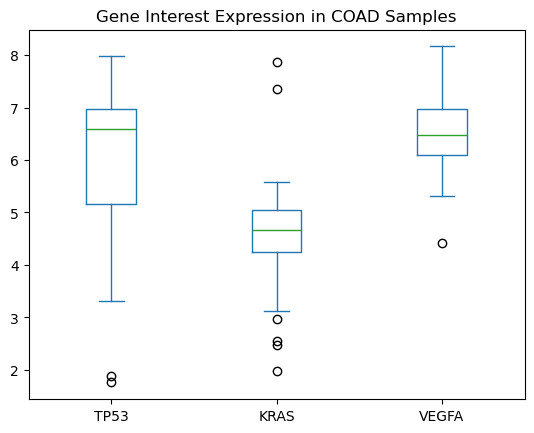

In [32]:
# Boxplot of Gene expression in COAD samples using PANDAS directly
COAD_merged[['TP53', 'KRAS', 'VEGFA']].plot.box()
plt.title("Gene Interest Expression in COAD Samples")
plt.show()

### Comapring Gene Expression via Scatterplot
We also wanted to test if we can use a scatterplot to compare the expression of a tumor suppression gene (KRAS) with an angiotensin gene (VEGFA). These two were chosen based on the boxplot image. This plot showed little to no correlation between the two. 

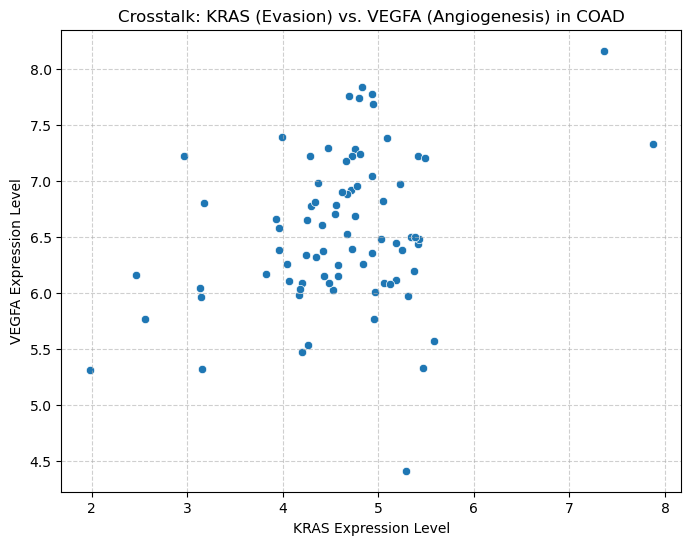

In [33]:

plt.figure(figsize=(8, 6))
sns.scatterplot(data=COAD_merged, x='KRAS', y='VEGFA')

plt.title("Crosstalk: KRAS (Evasion) vs. VEGFA (Angiogenesis) in COAD")
plt.xlabel("KRAS Expression Level")
plt.ylabel("VEGFA Expression Level")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Data Analysis: 

### Methods
The machine learning technique I am using is: *fill in and describe*

*What is this method optimizing? How does the model decide it is "good enough"?*

**

### Analysis
*(Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this can run your code to perform the analysis that you did, generate your figures, etc.)*

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## References:
https://pmc.ncbi.nlm.nih.gov/articles/PMC7281705/
https://medlineplus.gov/genetics/gene/kras/
https://blog.cellsignal.com/hallmarks-of-cancer-evading-growth-suppressors 
https://aacrjournals.org/pages/hm-evading-growth-suppressors
https://www.sciencedirect.com/science/article/pii/S0092867400816839?via%3Dihub
https://pmc.ncbi.nlm.nih.gov/articles/PMC5446472/#b1
https://seer.cancer.gov/statfacts/html/colorect.html
https://www.cancer.org/cancer/types/colon-rectal-cancer/causes-risks-prevention/risk-factors.html 



## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*